## 1. Project goal

Our selected species is: **Castor fiber**, also known as the Eurasian beaver.

### Business objective

The business objective is to understand the occurrence and observation intensity of *Castor fiber* based on the available dataset.

This can help with ecological monitoring, conservation planning, and understanding where and when the species is more likely to be observed.

### Data management goals (DMGs)

We want to predict the **number of Castor fiber observations** using the available dataset.

The target variable is `Castor fiber`.

This is a **regression problem** because the target variable is numeric/count-based. It contains values such as 0, 1, 2, 3 and higher.

A challenge is that most records have 0 observations, so the target variable is strongly skewed. This means we need to be careful when interpreting model performance.

The project is successful if:
- The dataset is understood and cleaned.
- The target variable is clearly defined.
- Important features related to *Castor fiber* observations are identified.
- Missing values, outliers, and data quality issues are documented.
- Preparation decisions are explained and justified.
- The data is prepared well enough to build a first baseline regression model.

### 2. Dataset overview

In [38]:
# Import the libraries we need for data understanding and visualisation.
# pandas is used for working with dataframes.
# numpy is used for numerical operations.
# matplotlib and seaborn are used for visualisations.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset.

df = pd.read_csv("Castor fiber.csv")
# Show the first five rows of the dataset.
# This helps us understand what the data looks like.

df.head()

C:\Users\becha\AppData\Local\Temp\ipykernel_24696\5697740.py:13: DtypeWarning: Columns (0: Castor fiber) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Castor fiber.csv")


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Castor fiber
0,50.75,5.65,2010-01-01,0.0,0,0
1,50.75,5.65,2010-01-02,26.0,0,0
2,50.75,5.65,2010-01-03,3.0,0,0
3,50.75,5.65,2010-01-04,0.0,0,0
4,50.75,5.65,2010-01-05,0.0,0,0


In [39]:
# Check the number of rows and columns.
df.shape

(12558786, 6)

In [40]:
# Check column names, data types, and non-null values.
# This helps us see which columns are numeric, categorical, or have missing values.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Castor fiber               object 
dtypes: float64(3), int64(1), object(1), str(1)
memory usage: 574.9+ MB


In [41]:
# Show summary statistics for numeric columns.
# This gives us the mean, standard deviation, min, max, and quartiles.
df.describe()

,decimalLatitude,decimalLongitude,total_observations,speciesgroup_observations
count,1.255879e+07,1.255879e+07,1.255878e+07,1.255879e+07
mean,5.222995e+01,5.532896e+00,8.122900e+00,2.240818e-01
std,6.647267e-01,8.779710e-01,4.830013e+01,2.517888e+00
min,3.500000e+00,3.350000e+00,0.000000e+00,0.000000e+00
25%,5.170000e+01,4.900000e+00,0.000000e+00,0.000000e+00
50%,5.220000e+01,5.650000e+00,1.000000e+00,0.000000e+00
75%,5.280000e+01,6.200000e+00,6.000000e+00,0.000000e+00
max,5.350000e+01,5.340000e+01,1.000400e+05,1.637000e+03


### 3. Target variable

The target variable is **Castor fiber**.

This column represents the number of *Castor fiber* observations for a specific location on a specific date.

At first, this could look like a presence/absence variable, but after checking the values, we found that the column contains more than only 0 and 1. It also contains values such as 2, 3, 5, 8 and higher.

Because of this, the original target variable is a **count variable**.

This means the project can be treated as a **regression problem**, because we want to predict a numeric value: the number of *Castor fiber* observations.

The other columns can be used as possible features:

- `decimalLatitude` = location latitude
- `decimalLongitude` = location longitude
- `eventDate` = date of the observation
- `total_observations` = total number of observations for that location/date
- `speciesgroup_observations` = number of observations from the related species group

Before modelling, we need to check the distribution of the target variable. If most values are 0, the target is heavily skewed. This can make modelling harder because the model may mostly learn to predict 0.

#### define and inspect target

In [42]:
# Define the target variable.
# The target is the column we want to predict.
# In this dataset, "Castor fiber" represents the number of Castor fiber observations.

target = "Castor fiber"

# Show the first few values of the target variable.
# This helps us inspect what kind of values the target contains.

# Convert the target column to numeric.
# errors="coerce" means that values that cannot be converted become NaN.
# This is useful because the target should be numeric/count-based.

df[target] = pd.to_numeric(df[target], errors="coerce")

df[target].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Castor fiber, dtype: float64

#### check target values

In [43]:
# Count how often each target value appears.
# This helps us see whether the target is binary or count-based.
# If the target only had 0 and 1, it could be used as binary classification.
# Since the target contains values higher than 1, we treat it as a numeric count variable.

df[target].value_counts(dropna=False).sort_index()

Castor fiber
-1.0             7
 0.0      12520453
 1.0         30707
 2.0          4971
 3.0          1358
 4.0           549
 5.0           232
 6.0           141
 7.0            89
 8.0            58
 9.0            38
 10.0           28
 11.0           16
 12.0           20
 13.0           18
 14.0           16
 15.0           10
 16.0            5
 17.0            8
 18.0            2
 19.0            3
 20.0            5
 21.0            4
 22.0            2
 23.0            2
 24.0            1
 25.0            2
 26.0            2
 27.0            2
 28.0            1
 29.0            2
 30.0            4
 31.0            1
 32.0            1
 33.0            2
 34.0            1
 35.0            1
 36.0            2
 37.0            2
 44.0            1
 52.0            1
 61.0            1
 62.0            1
 71.0            1
 72.0            1
 75.0            1
 81.0            1
 84.0            1
 88.0            2
 91.0            1
 93.0            1
 94.0            1

#### check target percentages

In [45]:
# Show the target distribution as percentages.
# This helps us understand how common each observation count is.
# In this dataset, we expect many records to have 0 Castor fiber observations.

target_percentages = df[target].value_counts(normalize=True, dropna=False).sort_index() * 100


#### Visualise target distribution

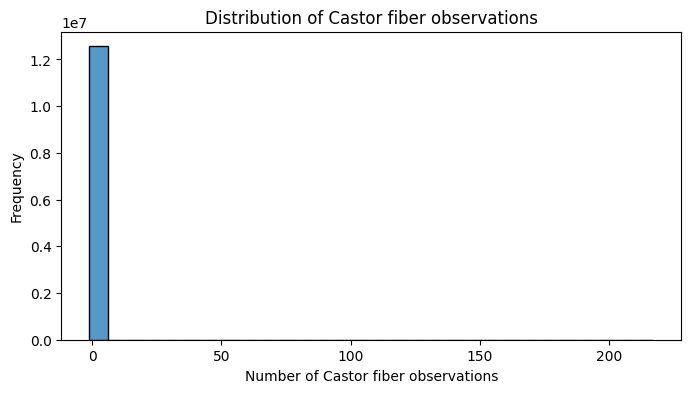

In [46]:
# Visualise the target variable.
# A histogram is suitable because the target is numeric/count-based.
# This shows how the number of Castor fiber observations is distributed.

plt.figure(figsize=(8, 4))
sns.histplot(df[target], bins=30)

plt.title("Distribution of Castor fiber observations")
plt.xlabel("Number of Castor fiber observations")
plt.ylabel("Frequency")
plt.show()

### 4. Missing values

### 5. Distributions

### 6. Outliers

### 7. Correlations with target


### 8. Multicollinearity

### 9. Transformations and scaling

### 10. Preparation decisions and next steps